In [1]:
# IrisPathQ Route Optimizer v0.3.2

#Classical preprocessing for quantum route optimization

#- Fuel and Distance calculations
#- Cost matrix construction

import subprocess
import os

print("IrisPathQ Route Optimizer v0.2")
print("Setting up C compilation environment...\n")

# gcc verification
result = subprocess.run(["gcc", "--version"], capture_output=True, text=True)
print(result.stdout.split('\n')[0])
print("\nReady for next step")

IrisPathQ Route Optimizer v0.2
Setting up C compilation environment...

gcc (GCC) 15.1.0

Ready for next step


In [2]:
%%writefile data_structures.h
/**
 * IrisPathQ Route Optimizer
 * Data structures for flights, routes, and optimization
*/

/**
 * Route Optimizer
*/

#ifndef DATA_STRUCTURES_H
#define DATA_STRUCTURES_H

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>

// Constants
#define MAX_FLIGHTS 500
#define MAX_WAYPOINTS 1000
#define MAX_ROUTES_PER_FLIGHT 10
#define MAX_WAYPOINTS_PER_ROUTE 50
#define EARTH_RADIUS_KM 6371.0
#define M_PI 3.14159265358979323846     //cuz I can use it rather than 3.14!

// Airport/Waypoint structure
typedef struct {
    char id[10];
    char name[50];
    double latitude;
    double longitude;
} Waypoint;

// Weather data
typedef struct {
    double latitude;
    double longitude;
    double wind_speed;      // knots
    double wind_direction;  // degrees
    double radius_nm;
    char severity[20];
    char weather_type[20];  // CLEAR, STORM, etc.
   
 
    
} Weather;

// Aircraft type
typedef struct {
    char type[10];          // B737, A320, etc.
    double cruise_speed;    // knots
    double fuel_burn_rate;  // kg per hour
    double max_range;       // nautical miles
} AircraftType;

// Flight information
typedef struct {
    char flight_id[10];
    char origin[10];
    char destination[10];
    char departure_time[10];
    AircraftType aircraft;
} Flight;

// Route (sequence of waypoints)
typedef struct {
    int waypoint_indices[MAX_WAYPOINTS_PER_ROUTE];
    int num_waypoints;
    double total_distance;  // nautical miles
    double fuel_cost;       // kg
    double time_cost;       // hours
    int conflict_count;     // number of conflicts with other routes
} Route;

// Problem instance
typedef struct {
    Flight flights[MAX_FLIGHTS];
    int num_flights;
    
    Waypoint waypoints[MAX_WAYPOINTS];
    int num_waypoints;
    
    Weather weather_cells[100];
    int num_weather_cells;
    
    Route routes[MAX_FLIGHTS][MAX_ROUTES_PER_FLIGHT];
    int num_routes_per_flight[MAX_FLIGHTS];
} ProblemInstance;

// Function declarations
double calculate_distance(double lat1, double lon1, double lat2, double lon2);
double calculate_fuel(Route *route, AircraftType *aircraft);
void print_route(Route *route, Waypoint *waypoints);
int is_in_hazard(double lat, double lon, Weather *weather_cells, int num_cells);
double calculate_wind_penalty(Waypoint *from, Waypoint *to, Weather *weather_cells, int num_cells);
double calculate_bearing(double lat1, double lon1, double lat2, double lon2);
double get_wind_component(double route_bearing, double wind_direction, double wind_speed);
int is_in_thunderstorm(double lat, double lon, Weather *weather_cells, int num_cells);

int load_flights(const char *filename, ProblemInstance *problem);
int load_waypoints(const char *filename, ProblemInstance *problem);
int load_weather(const char *filename, ProblemInstance *problem);
int generate_alternative_routes(ProblemInstance *problem, int flight_idx, int num_routes);
void inject_conflicts(ProblemInstance *problem);
void build_cost_matrix(ProblemInstance *problem, double **cost_matrix, int *matrix_size);
void export_cost_matrix(double *cost_matrix, int matrix_size, const char *filename);
void export_full_matrix(double *cost_matrix, int matrix_size, const char *filename);
int astar_find_route_with_weather(ProblemInstance *problem, int origin_idx, int destination_idx, Route *route);

#endif

Overwriting data_structures.h


In [4]:
%%writefile utils.c
    /**
     * IrisPathQ Route Optimizer
     * Distance and fuel calculations
    */
    
   #include "data_structures.h"

// Calculate great circle distance between two points AIRPATH
double calculate_distance(double lat1, double lon1, double lat2, double lon2) {
    double lat1_rad = lat1 * M_PI / 180.0;
    double lat2_rad = lat2 * M_PI / 180.0;
    double delta_lat = (lat2 - lat1) * M_PI / 180.0;
    double delta_lon = (lon2 - lon1) * M_PI / 180.0;
    
    double a = sin(delta_lat / 2.0) * sin(delta_lat / 2.0) +
               cos(lat1_rad) * cos(lat2_rad) *
               sin(delta_lon / 2.0) * sin(delta_lon / 2.0);
    
    double c = 2.0 * atan2(sqrt(a), sqrt(1.0 - a));
    double distance_km = EARTH_RADIUS_KM * c;
    
    // Convert to nautical miles (1 nm = 1.852 km)
    return distance_km / 1.852;
}

// Calculate fuel consumption for a route
double calculate_fuel(Route *route, AircraftType *aircraft) {
    double time_hours = route->total_distance / aircraft->cruise_speed;
    return time_hours * aircraft->fuel_burn_rate;
}

// Check if a waypoint is in a weather hazard zone
int is_in_hazard(double lat, double lon, Weather *weather_cells, int num_cells) {
    for (int i = 0; i < num_cells; i++) {
        if (strcmp(weather_cells[i].weather_type, "THUNDERSTORM") == 0) {
            double dist = calculate_distance(lat, lon, 
                                            weather_cells[i].latitude, 
                                            weather_cells[i].longitude);
            if (dist < 50.0) {  // Within 50nm of storm
                return 1;
            }
        }
    }
    return 0;
}
// Calculate bearing between two points (degrees)
double calculate_bearing(double lat1, double lon1, double lat2, double lon2) {
    lat1 = lat1 * M_PI / 180.0;
    lat2 = lat2 * M_PI / 180.0;
    double dLon = (lon2 - lon1) * M_PI / 180.0;
    
    double y = sin(dLon) * cos(lat2);
    double x = cos(lat1) * sin(lat2) - sin(lat1) * cos(lat2) * cos(dLon);
    double bearing = atan2(y, x);
    
    bearing = bearing * 180.0 / M_PI;
    bearing = fmod((bearing + 360.0), 360.0);  // Normalize to 0-360
    
    return bearing;
}

// Get wind component for a route segment
double get_wind_component(double route_bearing, double wind_direction, double wind_speed) {
    // Calculate angle between route and wind
    double angle_diff = fmod(fabs(route_bearing - wind_direction), 360.0);
    if (angle_diff > 180.0) {
        angle_diff = 360.0 - angle_diff;
    }
    
    // Headwind component (positive = headwind, negative = tailwind)
    double wind_component = wind_speed * cos(angle_diff * M_PI / 180.0);
    
    return wind_component;
}
// Calculate wind penalty for route segment
double calculate_wind_penalty(Waypoint *from, Waypoint *to, Weather *weather_cells, int num_cells) {
    // Find weather cell affecting this segment (use midpoint)
    double mid_lat = (from->latitude + to->latitude) / 2.0;
    double mid_lon = (from->longitude + to->longitude) / 2.0;
    
    // Find nearest weather cell
    Weather *active_weather = NULL;
    double min_dist = 999999.0;
    
    for (int i = 0; i < num_cells; i++) {
        double dist = calculate_distance(mid_lat, mid_lon, 
                                        weather_cells[i].latitude, 
                                        weather_cells[i].longitude);
        
        if (dist < weather_cells[i].radius_nm && dist < min_dist) {
            min_dist = dist;
            active_weather = &weather_cells[i];
        }
    }
    
    if (active_weather == NULL) {
        return 0.0;  // No weather impact
    }
    
    // Calculate route bearing
    double bearing = calculate_bearing(from->latitude, from->longitude,
                                      to->latitude, to->longitude);
    
    // Get headwind/tailwind component
    double wind_component = get_wind_component(bearing, 
                                              active_weather->wind_direction,
                                              active_weather->wind_speed);
    
    // Convert to fuel penalty
    // Headwind: +50 knots = +5% fuel = +50 kg per 1000 nm
    // Tailwind: -50 knots = -5% fuel = -50 kg per 1000 nm
    double distance_nm = calculate_distance(from->latitude, from->longitude,
                                           to->latitude, to->longitude);
    
    double fuel_penalty = (wind_component / 10.0) * (distance_nm / 1000.0) * 100.0;
    
    return fuel_penalty;  // kg of extra fuel
}

// Check if waypoint is in thunderstorm zone
int is_in_thunderstorm(double lat, double lon, Weather *weather_cells, int num_cells) {
    for (int i = 0; i < num_cells; i++) {
        if (strcmp(weather_cells[i].weather_type, "THUNDERSTORM") != 0) {
            continue;  // Not a thunderstorm
        }
        
        double dist = calculate_distance(lat, lon,
                                        weather_cells[i].latitude,
                                        weather_cells[i].longitude);
        
        if (dist <= weather_cells[i].radius_nm) {
            return 1;  // Inside thunderstorm zone
        }
    }
    return 0;  // Clear
}

// Print route details
void print_route(Route *route, Waypoint *waypoints) {
    printf("Route: ");
    for (int i = 0; i < route->num_waypoints; i++) {
        printf("%s ", waypoints[route->waypoint_indices[i]].id);
        if (i < route->num_waypoints - 1) printf("-> ");
    }
    printf("\n");
    printf("Distance: %.2f nm, Fuel: %.2f kg, Time: %.2f hrs\n",
           route->total_distance, route->fuel_cost, route->time_cost);
}

Overwriting utils.c


In [5]:
%%writefile data_loader.c
/**
 * IrisPathQ Route Optimizer
 * Load flights, waypoints, and weather data from CSV files
*/

#include "data_structures.h"

// Load sample flights from file
int load_flights(const char *filename, ProblemInstance *problem) {
    FILE *file = fopen(filename, "r");
    if (!file) {
        printf("Error: Cannot open %s\n", filename);
        return -1;
    }
    
    char line[256];
    fgets(line, sizeof(line), file);  // Skip header
    
    problem->num_flights = 0;
    while (fgets(line, sizeof(line), file) && problem->num_flights < MAX_FLIGHTS) {
        Flight *f = &problem->flights[problem->num_flights];
        
        sscanf(line, "%[^,],%[^,],%[^,],%[^,],%s",
               f->flight_id, f->origin, f->destination, 
               f->departure_time, f->aircraft.type);
        
        // Setting up aircraft parameters based on type [not official numbers]
        if (strcmp(f->aircraft.type, "B737") == 0) {
            f->aircraft.cruise_speed = 450.0;
            f->aircraft.fuel_burn_rate = 2500.0;
            f->aircraft.max_range = 3000.0;
        } else if (strcmp(f->aircraft.type, "A320") == 0) {
            f->aircraft.cruise_speed = 450.0;
            f->aircraft.fuel_burn_rate = 2400.0;
            f->aircraft.max_range = 3200.0;
        } else {  // Default
            f->aircraft.cruise_speed = 450.0;
            f->aircraft.fuel_burn_rate = 2500.0;
            f->aircraft.max_range = 3000.0;
        }
        
        problem->num_flights++;
    }
    
    fclose(file);
    printf("Loaded %d flights\n", problem->num_flights);
    return problem->num_flights;
}

// Load waypoints
int load_waypoints(const char *filename, ProblemInstance *problem) {
    FILE *file = fopen(filename, "r");
    if (!file) {
        printf("Error: Cannot open %s\n", filename);
        return -1;
    }
    
    char line[256];
    fgets(line, sizeof(line), file);  // Skip header
    
    problem->num_waypoints = 0;
    while (fgets(line, sizeof(line), file) && problem->num_waypoints < MAX_WAYPOINTS) {
        Waypoint *w = &problem->waypoints[problem->num_waypoints];
        
        sscanf(line, "%[^,],%lf,%lf,%s",
               w->id, &w->latitude, &w->longitude, w->name);
        
        problem->num_waypoints++;
    }
    
    fclose(file);
    printf("Loaded %d waypoints\n", problem->num_waypoints);
    return problem->num_waypoints;
}

// Load weather data
int load_weather(const char *filename, ProblemInstance *problem) {
    FILE *file = fopen(filename, "r");
    if (!file) {
        printf("Error: Cannot open %s\n", filename);
        return -1;
    }
    
    char line[256];
    fgets(line, sizeof(line), file);  // Skip header
    
    problem->num_weather_cells = 0;
    while (fgets(line, sizeof(line), file) && problem->num_weather_cells < 100) {
        Weather *w = &problem->weather_cells[problem->num_weather_cells];
        
         sscanf(line, "%lf,%lf,%lf,%lf,%lf,%[^,],%s",
               &w->latitude,           // Column 1
               &w->longitude,          // Column 2
               &w->wind_speed,         // Column 3
               &w->wind_direction,     // Column 4
               &w->radius_nm,          // Column 5
               w->severity,            // Column 6 (reads until comma)
               w->weather_type);       // Column 7
        
        problem->num_weather_cells++;

        // Debug
        printf("  Loaded: %s at (%.1f, %.1f), radius=%.0f nm, type=%s\n",
               w->weather_type, w->latitude, w->longitude, 
               w->radius_nm, w->weather_type);
    }
    
    fclose(file);
    printf("Loaded %d weather cells\n", problem->num_weather_cells);
    return problem->num_weather_cells;
}

Overwriting data_loader.c


In [6]:
%%writefile astar.c
#include "data_structures.h"
#include <float.h>

// Priority queue node for A*
typedef struct PQNode {
    int waypoint_index;
    double g_cost;  // Actual cost from start
    double h_cost;  // Heuristic cost to goal
    double f_cost;  // g + h
    int parent_index;
    struct PQNode *next;
} PQNode;

// Priority queue (min-heap as linked list for simplicity)
typedef struct {
    PQNode *head;
    int size;
} PriorityQueue;

// Initialize priority queue
void pq_init(PriorityQueue *pq) {
    pq->head = NULL;
    pq->size = 0;
}

// Insert into priority queue (sorted by f_cost)
void pq_insert(PriorityQueue *pq, int waypoint_index, double g_cost, double h_cost, int parent_index) {
    PQNode *new_node = (PQNode*)malloc(sizeof(PQNode));
    new_node->waypoint_index = waypoint_index;
    new_node->g_cost = g_cost;
    new_node->h_cost = h_cost;
    new_node->f_cost = g_cost + h_cost;
    new_node->parent_index = parent_index;
    new_node->next = NULL;
    
    // Insert in sorted order
    if (pq->head == NULL || pq->head->f_cost > new_node->f_cost) {
        new_node->next = pq->head;
        pq->head = new_node;
    } else {
        PQNode *current = pq->head;
        while (current->next != NULL && current->next->f_cost <= new_node->f_cost) {
            current = current->next;
        }
        new_node->next = current->next;
        current->next = new_node;
    }
    pq->size++;
}

// Extract minimum from priority queue
PQNode pq_extract_min(PriorityQueue *pq) {
    if (pq->head == NULL) {
        PQNode empty = {-1, 0, 0, 0, -1, NULL};
        return empty;
    }
    
    PQNode *min_node = pq->head;
    PQNode result = *min_node;
    pq->head = min_node->next;
    free(min_node);
    pq->size--;
    
    return result;
}

// Check if priority queue is empty
int pq_is_empty(PriorityQueue *pq) {
    return pq->size == 0;
}

// Free priority queue
void pq_free(PriorityQueue *pq) {
    while (pq->head != NULL) {
        PQNode *temp = pq->head;
        pq->head = pq->head->next;
        free(temp);
    }
}

// Heuristic: Straight-line distance (great circle)
double heuristic(Waypoint *from, Waypoint *to) {
    return calculate_distance(from->latitude, from->longitude,to->latitude, to->longitude);
}

// Check if waypoint is in weather hazard (from utils.c)
extern int is_in_hazard(double lat, double lon, Weather *weather_cells, int num_cells);

// A* pathfinding algorithm
int astar_find_route(ProblemInstance *problem, int origin_idx, int destination_idx, Route *route) {
    Waypoint *waypoints = problem->waypoints;
    int num_waypoints = problem->num_waypoints;
    Weather *weather = problem->weather_cells;
    int num_weather = problem->num_weather_cells;
    
    // Initialize data structures
    double g_cost[MAX_WAYPOINTS];
    int parent[MAX_WAYPOINTS];
    int visited[MAX_WAYPOINTS];
    
    for (int i = 0; i < num_waypoints; i++) {
        g_cost[i] = DBL_MAX;
        parent[i] = -1;
        visited[i] = 0;
    }
    
    g_cost[origin_idx] = 0.0;
    
    // Priority queue
    PriorityQueue pq;
    pq_init(&pq);
    
    double h = heuristic(&waypoints[origin_idx], &waypoints[destination_idx]);
    pq_insert(&pq, origin_idx, 0.0, h, -1);
    
    int found = 0;
    
    // A* main loop
    while (!pq_is_empty(&pq)) {
        PQNode current = pq_extract_min(&pq);
        int current_idx = current.waypoint_index;
        
        // Goal reached
        if (current_idx == destination_idx) {
            found = 1;
            break;
        }
        
        // Skip if already visited
        if (visited[current_idx]) {
            continue;
        }
        visited[current_idx] = 1;
        
        // Explore neighbors (for simplicity, consider all waypoints as potential neighbors)
        // Airways to be used here 
        for (int neighbor_idx = 0; neighbor_idx < num_waypoints; neighbor_idx++) {
            if (neighbor_idx == current_idx || visited[neighbor_idx]) {
                continue;
            }
            
            // Calculate distance to neighbor
            double edge_cost = calculate_distance(
                waypoints[current_idx].latitude, waypoints[current_idx].longitude,
                waypoints[neighbor_idx].latitude, waypoints[neighbor_idx].longitude
            );
            
            // Skip if too far 
            if (edge_cost > 3000.0) {  // Max 500nm between waypoints too less
                continue;
            }
            
            // Add penalty for weather hazards
            if (is_in_hazard(waypoints[neighbor_idx].latitude, 
                           waypoints[neighbor_idx].longitude,
                           weather, num_weather)) {
                edge_cost *= 2.0;  // Double the cost for hazardous areas
            }
            
            // Calculate tentative g_cost
            double tentative_g = g_cost[current_idx] + edge_cost;
            
            // Update if better path found
            if (tentative_g < g_cost[neighbor_idx]) {
                g_cost[neighbor_idx] = tentative_g;
                parent[neighbor_idx] = current_idx;
                
                double h = heuristic(&waypoints[neighbor_idx], &waypoints[destination_idx]);
                pq_insert(&pq, neighbor_idx, tentative_g, h, current_idx);
            }
        }
    }
    
    pq_free(&pq);
    
    if (!found) {
        printf("No route found from %s to %s\n", 
               waypoints[origin_idx].id, waypoints[destination_idx].id);
        return -1;
    }
    
    // Reconstruct path
    int path[MAX_WAYPOINTS_PER_ROUTE];
    int path_length = 0;
    int current = destination_idx;
    
    while (current != -1) {
        path[path_length++] = current;
        current = parent[current];
    }
    
    // Reverse path (it's built backwards)
    route->num_waypoints = path_length;
    for (int i = 0; i < path_length; i++) {
        route->waypoint_indices[i] = path[path_length - 1 - i];
    }
    
    // Calculate total distance and fuel
    route->total_distance = g_cost[destination_idx];
    route->conflict_count = 0;  // Will be calculated later  no conflicts yet 
    
    return 0;
}
/**
 * A* pathfinding with waypoint exclusions to force alternative routes
 * blocked[i] = 1 means waypoint i cannot be used
 */
int astar_with_exclusions(ProblemInstance *problem, int origin_idx, int destination_idx, 
                          Route *route, int *blocked) {
    Waypoint *waypoints = problem->waypoints;
    int num_waypoints = problem->num_waypoints;
    Weather *weather = problem->weather_cells;
    int num_weather = problem->num_weather_cells;
    
    // Initialize data structures
    double g_cost[MAX_WAYPOINTS];
    int parent[MAX_WAYPOINTS];
    int visited[MAX_WAYPOINTS];
    
    for (int i = 0; i < num_waypoints; i++) {
        g_cost[i] = DBL_MAX;
        parent[i] = -1;
        visited[i] = 0;
    }
    
    g_cost[origin_idx] = 0.0;
    
    // Priority queue
    PriorityQueue pq;
    pq_init(&pq);
    
    double h = heuristic(&waypoints[origin_idx], &waypoints[destination_idx]);
    pq_insert(&pq, origin_idx, 0.0, h, -1);
    
    int found = 0;
    
    // A* main loop with exclusions
    while (!pq_is_empty(&pq)) {
        PQNode current = pq_extract_min(&pq);
        int current_idx = current.waypoint_index;
        
        if (current_idx == destination_idx) {
            found = 1;
            break;
        }
        
        if (visited[current_idx]) {
            continue;
        }
        visited[current_idx] = 1;
        
        // Explore neighbors
        for (int neighbor_idx = 0; neighbor_idx < num_waypoints; neighbor_idx++) {
            if (neighbor_idx == current_idx || visited[neighbor_idx]) {
                continue;
            }
            
            // SKIP BLOCKED WAYPOINTS (unless it's the destination)
            if (blocked[neighbor_idx] && neighbor_idx != destination_idx) {
                continue;
            }
            
            // BASE COST: Geographic distance
            double edge_cost = calculate_distance(
                waypoints[current_idx].latitude, waypoints[current_idx].longitude,
                waypoints[neighbor_idx].latitude, waypoints[neighbor_idx].longitude
            );
            
            // Skip if too far
            if (edge_cost > 3000.0) {
                continue;
            }
            
            // WEATHER PENALTY 1: Thunderstorms
            if (is_in_thunderstorm(waypoints[neighbor_idx].latitude,
                                  waypoints[neighbor_idx].longitude,
                                  weather, num_weather)) {
                edge_cost *= 5.0;
            }
            
            // WEATHER PENALTY 2: Wind
            double wind_penalty = calculate_wind_penalty(
                &waypoints[current_idx],
                &waypoints[neighbor_idx],
                weather, num_weather
            );
            edge_cost += wind_penalty;
            
            // Calculate tentative g_cost
            double tentative_g = g_cost[current_idx] + edge_cost;
            
            // Update if better path found
            if (tentative_g < g_cost[neighbor_idx]) {
                g_cost[neighbor_idx] = tentative_g;
                parent[neighbor_idx] = current_idx;
                
                double h = heuristic(&waypoints[neighbor_idx], 
                                    &waypoints[destination_idx]);
                pq_insert(&pq, neighbor_idx, tentative_g, h, current_idx);
            }
        }
    }
    
    pq_free(&pq);
    
    if (!found) {
        printf("No alternative route found from %s to %s (exclusions too restrictive)\n",
               waypoints[origin_idx].id, waypoints[destination_idx].id);
        return -1;
    }
    
    // Reconstruct path
    int path[MAX_WAYPOINTS_PER_ROUTE];
    int path_length = 0;
    int current = destination_idx;
    
    while (current != -1) {
        path[path_length++] = current;
        current = parent[current];
    }
    
    // Reverse path
    route->num_waypoints = path_length;
    for (int i = 0; i < path_length; i++) {
        route->waypoint_indices[i] = path[path_length - 1 - i];
    }
    
    route->total_distance = g_cost[destination_idx];
    route->conflict_count = 0;
    
    return 0;
}


int generate_alternative_routes(ProblemInstance *problem, int flight_idx, int num_routes) {
    Flight *flight = &problem->flights[flight_idx];
    
    // Find origin and destination waypoint indices
    int origin_idx = -1, dest_idx = -1;
    for (int i = 0; i < problem->num_waypoints; i++) {
        if (strcmp(problem->waypoints[i].id, flight->origin) == 0) {
            origin_idx = i;
        }
        if (strcmp(problem->waypoints[i].id, flight->destination) == 0) {
            dest_idx = i;
        }
    }
    
    if (origin_idx == -1 || dest_idx == -1) {
        printf("Error: Origin or destination not found for flight %s\n", flight->flight_id);
        return -1;
    }
    
    printf("Generating %d routes for %s: %s -> %s\n", 
           num_routes, flight->flight_id, flight->origin, flight->destination);
    
    // Initialize route counter
    problem->num_routes_per_flight[flight_idx] = 0;
    
    // Generate Route 0: Direct/Optimal
    Route *route0 = &problem->routes[flight_idx][0];
    if (astar_find_route_with_weather(problem, origin_idx, dest_idx, route0) == 0) {
        route0->fuel_cost = calculate_fuel(route0, &flight->aircraft);
        route0->time_cost = route0->total_distance / flight->aircraft.cruise_speed;
         // Apply strategic adjustments to Route 0
        int r = 0;  // Route 0
        if (flight_idx == 0) {
            if (r == 0) route0->fuel_cost *= 1.25;
        }
        if (flight_idx == 1) {
            if (r == 0) route0->fuel_cost *= 1.20;
        }
        if (flight_idx == 2) {
            if (r == 0) route0->fuel_cost *= 1.30;
        }
        if (flight_idx == 4) {
            if (r == 0) route0->fuel_cost *= 1.15;
        }
        printf("  Route 0: ");
        print_route(route0, problem->waypoints);
        problem->num_routes_per_flight[flight_idx]++;
    }
    
    // Generate Routes 1-4: Force via different waypoints
    int waypoints_to_try[] = {-1, -1, -1, -1};
    int num_via_points = 0;
    
    // Find intermediate waypoints (not origin, not destination)
    for (int w = 0; w < problem->num_waypoints && num_via_points < 4; w++) {
        if (w != origin_idx && w != dest_idx) {
            waypoints_to_try[num_via_points++] = w;
        }
    }
    
    // Generate alternative routes via each intermediate waypoint
    for (int r = 1; r < num_routes && r <= num_via_points; r++) {
        Route *route = &problem->routes[flight_idx][r];
        int via_idx = waypoints_to_try[r - 1];
        
        // Build route: Origin -> VIA -> Destination
        Route leg1, leg2;
        
        int success1 = (astar_find_route_with_weather(problem, origin_idx, via_idx, &leg1) == 0);
        int success2 = (astar_find_route_with_weather(problem, via_idx, dest_idx, &leg2) == 0);
        
        if (success1 && success2) {
            // Combine both legs
            route->num_waypoints = 0;
            
            // Add leg1 waypoints
            for (int i = 0; i < leg1.num_waypoints; i++) {
                route->waypoint_indices[route->num_waypoints++] = leg1.waypoint_indices[i];
            }
            
            // Add leg2 waypoints (skip first, it's the via point already added)
            for (int i = 1; i < leg2.num_waypoints; i++) {
                route->waypoint_indices[route->num_waypoints++] = leg2.waypoint_indices[i];
            }
            
            route->total_distance = leg1.total_distance + leg2.total_distance;
            route->fuel_cost = calculate_fuel(route, &flight->aircraft);
            route->time_cost = route->total_distance / flight->aircraft.cruise_speed;
            
            
            // STRATEGIC COST ADJUSTMENTS to create optimization opportunities
            if (flight_idx == 0) {
                // Flight 0: Route 2 gets priority clearance
                if (r == 2) route->fuel_cost *= 0.80;  // 20% savings!
                // Route 0 has traffic delays
                if (r == 0) route->fuel_cost *= 1.25;  // 25% penalty
            }
            
            if (flight_idx == 1) {
                // Flight 1: Route 3 has optimal jet stream
                if (r == 3) route->fuel_cost *= 0.85;  // 15% savings
                // Route 0 has holding pattern
                if (r == 0) route->fuel_cost *= 1.20;
            }
            
            if (flight_idx == 2) {
                // Flight 2: Route 4 gets express lane
                if (r == 4) route->fuel_cost *= 0.75;  // 25% savings!
                if (r == 1) route->fuel_cost *= 0.90;
                // Route 0 has weather delays
                if (r == 0) route->fuel_cost *= 1.30;
            }
            
            if (flight_idx == 3) {
                // Flight 3: Route 4 has tailwinds
                if (r == 4) route->fuel_cost *= 0.70;  // 30% savings!
                // Route 0 is standard
            }
            
            if (flight_idx == 4) {
                // Flight 4: Route 2 optimal altitude
                if (r == 2) route->fuel_cost *= 0.85;
                // Route 0 has minor delays
                if (r == 0) route->fuel_cost *= 1.15;
            }
            
            
            //printf("  Route %d: ", r);
           // print_route(route, problem->waypoints);
            
           // problem->num_routes_per_flight[flight_idx]++;
            
            printf("  Route %d: ", r);
            print_route(route, problem->waypoints);
            
            problem->num_routes_per_flight[flight_idx]++;
        } else {
            printf("  Route %d: Failed via %s\n", r, problem->waypoints[via_idx].id);
        }
    }
    
    // If we couldn't generate enough alternatives, duplicate the best route with penalties
   /* while (problem->num_routes_per_flight[flight_idx] < num_routes) {
        int r = problem->num_routes_per_flight[flight_idx];
        Route *route = &problem->routes[flight_idx][r];
        Route *base = &problem->routes[flight_idx][0];
        
        // Copy Route 0
        *route = *base;
        
        // Add artificial penalty (simulates longer route)
        route->fuel_cost *= (1.0 + (r * 0.05));  // 5%, 10%, 15% more expensive
        route->time_cost *= (1.0 + (r * 0.05));
        
        printf("  Route %d: (Duplicate with +%.0f%% penalty)\n", r, (r * 5.0));
        
        problem->num_routes_per_flight[flight_idx]++;
    }*/
    
    printf("  Generated %d/%d routes\n\n", 
           problem->num_routes_per_flight[flight_idx], num_routes);
    
    return problem->num_routes_per_flight[flight_idx];
}

//Artificial Conflicts for now 
//For each flight N, it takes the second-last waypoint from Flight Ns Route 0 and 
//inserts that waypoint into the second position of Flight N1s Route 0. e.g 
//Flight 1 -> A->B->C->D
//Flight2 -> F->G->H->I
//fucntion will make flight 2 path t  go via B new route F2: F->A->GHI
//for Route 0 of every plane    
// Build cost matrix for QUBO encoding

void build_cost_matrix(ProblemInstance *problem, double **cost_matrix, int *matrix_size) {
    // Calculate total number of variables
    int total_vars = 0;
    for (int i = 0; i < problem->num_flights; i++) {
        total_vars += problem->num_routes_per_flight[i];
    }
    
    *matrix_size = total_vars;
    
    // Allocate matrix
    *cost_matrix = (double*)calloc(total_vars * total_vars, sizeof(double));
    
    printf("\nBuilding cost matrix (%d x %d)...\n", total_vars, total_vars);
    
    int var_index = 0;
    
    // Fill diagonal with route costs
    for (int flight = 0; flight < problem->num_flights; flight++) {
        for (int route = 0; route < problem->num_routes_per_flight[flight]; route++) {
            double fuel_cost = problem->routes[flight][route].fuel_cost;
            (*cost_matrix)[var_index * total_vars + var_index] = fuel_cost;
            var_index++;
        }
    }
    
    // Fill off-diagonal with conflict penalties
    int var_i = 0;
    int total_conflicts = 0;
    double total_penalty = 0.0;  // NEW: Track total penalty amount
    
    for (int flight_i = 0; flight_i < problem->num_flights; flight_i++) {
        for (int route_i = 0; route_i < problem->num_routes_per_flight[flight_i]; route_i++) {
            
            int var_j = 0;
            for (int flight_j = 0; flight_j < problem->num_flights; flight_j++) {
                if (flight_i == flight_j) {
                    var_j += problem->num_routes_per_flight[flight_j];
                    continue;
                }
                
                for (int route_j = 0; route_j < problem->num_routes_per_flight[flight_j]; route_j++) {
                    Route *r1 = &problem->routes[flight_i][route_i];
                    Route *r2 = &problem->routes[flight_j][route_j];
                    
                    int conflict = 0;
                    for (int w1 = 0; w1 < r1->num_waypoints; w1++) {
                        for (int w2 = 0; w2 < r2->num_waypoints; w2++) {
                            if (r1->waypoint_indices[w1] == r2->waypoint_indices[w2]) {
                                conflict = 1;
                                break;
                            }
                        }
                        if (conflict) break;
                    }
                   
                    if (conflict) {
                        double penalty = 10000.0;
                        (*cost_matrix)[var_i * total_vars + var_j] = penalty;
                        (*cost_matrix)[var_j * total_vars + var_i] = penalty;
                        
                        // Only count once (avoid double-counting symmetric matrix)
                        if (var_i < var_j) {
                            total_conflicts++;
                            total_penalty += penalty;
                            
                            // Print with penalty amount
                            printf("  CONFLICT #%d: Flight %s Route %d <-> Flight %s Route %d (Penalty: %.0f kg)\n",
                                   total_conflicts,
                                   problem->flights[flight_i].flight_id, route_i,
                                   problem->flights[flight_j].flight_id, route_j,
                                   penalty);
                        }
                    }
                    
                    var_j++;
                }
            }
            var_i++;
        }
    }
    
    printf("\n Cost matrix built successfully\n");
    printf("   Total conflicts: %d\n", total_conflicts);
    printf("   Total penalty if all triggered: %.0f kg\n", total_penalty);
    printf("   Quantum must explore combinations to avoid these penalties!\n");
}

// Export cost matrix to file (for quantum processing)
void export_cost_matrix(double *cost_matrix, int matrix_size, const char *filename) {
    FILE *file = fopen(filename, "w");
    if (!file) {
        printf("Error: Cannot open %s for writing\n", filename);
        return;
    }
    
    fprintf(file, "%d\n", matrix_size);  // First line: matrix size
    
    // Write matrix (sparse format: only non-zero entries)
    for (int i = 0; i < matrix_size; i++) {
        for (int j = 0; j < matrix_size; j++) {
            double value = cost_matrix[i * matrix_size + j];
            if (value != 0.0) {        // removing the zeros creating sparse matrix 
                fprintf(file, "%d,%d,%.2f\n", i, j, value);
            }
        }
    }
    
    fclose(file);
    printf("Cost matrix exported to %s\n", filename);
}




// Exporting full dense matrix (for debugging)
void export_full_matrix(double *cost_matrix, int matrix_size, const char *filename) {
    FILE *file = fopen(filename, "w");
    if (!file) {
        printf("Error: Cannot open %s for writing\n", filename);
        return;
    }
    
    fprintf(file, "Full Cost Matrix (%d x %d)\n", matrix_size, matrix_size);
    fprintf(file, "================================\n\n");
    
    // Column headers
    fprintf(file, "      ");
    for (int j = 0; j < matrix_size; j++) {
        fprintf(file, "Col%-5d ", j);
    }
    fprintf(file, "\n");
    
    fprintf(file, "      ");
    for (int j = 0; j < matrix_size; j++) {
        fprintf(file, "-------- ");
    }
    fprintf(file, "\n");
    
    // Matrix rows
    for (int i = 0; i < matrix_size; i++) {
        fprintf(file, "Row%-2d | ", i);
        
        for (int j = 0; j < matrix_size; j++) {
            double value = cost_matrix[i * matrix_size + j];
            
            if (value == 0.0) {
                fprintf(file, "    0    ");  // Zero entry
            } else if (i == j) {
            // Diagonal: always show the number (it's fuel cost)
            fprintf(file, "%8.0f ", value);
            } else if (value >= 10000.0) {
            // Off-diagonal: large value = conflict
                fprintf(file, " CONFLICT");
            } else {
                fprintf(file, "%8.0f ", value);  // Regular cost
            }
        }
        fprintf(file, "\n");
    }
    
    fprintf(file, "\n================================\n");
    fprintf(file, "Legend:\n");
    fprintf(file, "  Diagonal entries = Fuel costs (kg)\n");
    fprintf(file, " (0,0) is flight 0 taking route 0 its fuel cost, where rows 0 to 4 is flight routes fro the zeroth flight(AC101), similary col 0 to 4 is allroutes available for Flight 0  \n");
    fprintf(file, "  CONFLICT = Route conflict penalty; No conflicts for now (10000+ kg)\n");
    fprintf(file, "  0 = No interaction\n");
    
    fclose(file);
    printf("Full matrix exported to %s\n", filename);
}

/*
 * This function applies the A* pathfinding algorithm to compute a route from a given origin
 * waypoint to a destination waypoint. It integrates weather-impact data such as thunderstorms
 * and wind conditions to modify the edge costs dynamically, penalizing inefficient
 * path segments.
 */

int astar_find_route_with_weather(ProblemInstance *problem, int origin_idx, int destination_idx, Route *route) {
    Waypoint *waypoints = problem->waypoints;
    int num_waypoints = problem->num_waypoints;
    Weather *weather = problem->weather_cells;
    int num_weather = problem->num_weather_cells;
    
    // Initialize A* data structures (same as before)
    double g_cost[MAX_WAYPOINTS];
    int parent[MAX_WAYPOINTS];
    int visited[MAX_WAYPOINTS];
    
    for (int i = 0; i < num_waypoints; i++) {
        g_cost[i] = DBL_MAX;
        parent[i] = -1;
        visited[i] = 0;
    }
    
    g_cost[origin_idx] = 0.0;
    
    PriorityQueue pq;
    pq_init(&pq);
    
    double h = heuristic(&waypoints[origin_idx], &waypoints[destination_idx]);
    pq_insert(&pq, origin_idx, 0.0, h, -1);
    
    int found = 0;
    
    // A* main loop
    while (!pq_is_empty(&pq)) {
        PQNode current = pq_extract_min(&pq);
        int current_idx = current.waypoint_index;
        
        if (current_idx == destination_idx) {
            found = 1;
            break;
        }
        
        if (visited[current_idx]) {
            continue;
        }
        visited[current_idx] = 1;
        
        // Explore neighbors
        for (int neighbor_idx = 0; neighbor_idx < num_waypoints; neighbor_idx++) {
            if (neighbor_idx == current_idx || visited[neighbor_idx]) {
                continue;
            }
            
            // BASE COST: Geographic distance
            double edge_cost = calculate_distance(
                waypoints[current_idx].latitude, waypoints[current_idx].longitude,
                waypoints[neighbor_idx].latitude, waypoints[neighbor_idx].longitude
            );
            
            // Skip if too far (not a realistic connection)
            if (edge_cost > 3000.0) {
                continue;
            }
            
            // WEATHER PENALTY 1: Thunderstorms (HARD AVOID)
            if (is_in_thunderstorm(waypoints[neighbor_idx].latitude,
                                  waypoints[neighbor_idx].longitude,
                                  weather, num_weather)) {
                edge_cost *= 5.0;  // 5x penalty = effective avoidance
                printf(" Thunderstorm at %s (penalty applied)\n", 
                       waypoints[neighbor_idx].id);
            }
            
            // WEATHER PENALTY 2: Wind (FUEL IMPACT)
            double wind_penalty = calculate_wind_penalty(
                &waypoints[current_idx],
                &waypoints[neighbor_idx],
                weather, num_weather
            );
            edge_cost += wind_penalty;
            
            // Calculate tentative g_cost
            double tentative_g = g_cost[current_idx] + edge_cost;
            
            // Update if better path found
            if (tentative_g < g_cost[neighbor_idx]) {
                g_cost[neighbor_idx] = tentative_g;
                parent[neighbor_idx] = current_idx;
                
                double h = heuristic(&waypoints[neighbor_idx], 
                                    &waypoints[destination_idx]);
                pq_insert(&pq, neighbor_idx, tentative_g, h, current_idx);
            }
        }
    }
    
    pq_free(&pq);
    
    if (!found) {
        printf("No route found from %s to %s (weather blocked?)\n",
               waypoints[origin_idx].id, waypoints[destination_idx].id);
        return -1;
    }
    
    // Reconstruct path (same as before)
    int path[MAX_WAYPOINTS_PER_ROUTE];
    int path_length = 0;
    int current = destination_idx;
    
    while (current != -1) {
        path[path_length++] = current;
        current = parent[current];
    }
    
    // Reverse path
    route->num_waypoints = path_length;
    for (int i = 0; i < path_length; i++) {
        route->waypoint_indices[i] = path[path_length - 1 - i];
    }
    
    route->total_distance = g_cost[destination_idx];
    route->conflict_count = 0;
    
    return 0;
}

Overwriting astar.c


In [7]:
%%writefile main.c
/**
 * IrisPathQ Route Optimizer
 * Main program - data loading, route generation, and cost matrix creation
*/

#include "data_structures.h"



int main() {
    printf("====================================\n");
    printf("Route Optimization\n");
    printf("====================================\n\n");
    
    // Initialize problem instance
    ProblemInstance problem;
    memset(&problem, 0, sizeof(ProblemInstance));
    
    // Load data
    printf("Loading data...\n");
    load_flights("data/flights.csv", &problem);
    load_waypoints("data/waypoints.csv", &problem);
    load_weather("data/weatherTS3.csv", &problem);
    
    //DEBUG
    printf("\n=== STORM CHECK ===\n");
for (int i = 0; i < problem.num_waypoints; i++) {
    for (int j = 0; j < problem.num_weather_cells; j++) {
        if (strcmp(problem.weather_cells[j].weather_type, "THUNDERSTORM") == 0) {
            double dist = calculate_distance(
                problem.waypoints[i].latitude, problem.waypoints[i].longitude,
                problem.weather_cells[j].latitude, problem.weather_cells[j].longitude
            );
            if (dist < problem.weather_cells[j].radius_nm) {
                printf("  %s is INSIDE storm at (%.1f, %.1f) - distance: %.2f nm\n",
                       problem.waypoints[i].id, 
                       problem.weather_cells[j].latitude,
                       problem.weather_cells[j].longitude,
                       dist);
            }
        }
    }
}

    printf("\n====================================\n");
    printf("Generating Routes\n");
    printf("====================================\n\n");
    
    // Generate 5 alternative routes for each flight
    int num_alternative_routes = 5;
    for (int i = 0; i < problem.num_flights; i++) {
        generate_alternative_routes(&problem, i, num_alternative_routes);
        printf("\n");
    }
    
    //Conflict
    //inject_conflicts(&problem);


    printf("\n====================================\n");
    printf("Building Cost Matrix \n");
    printf("====================================\n\n");
    
    // Build cost matrix
    double *cost_matrix = NULL;
    int matrix_size = 0;
    build_cost_matrix(&problem, &cost_matrix, &matrix_size);
    
    // Export for quantum processing
    export_cost_matrix(cost_matrix, matrix_size, "output/cost_matrix.txt");


    export_full_matrix(cost_matrix, matrix_size, "output/full_matrix.txt");
    
    printf("\n====================================\n");
    printf("Summary\n");
    printf("====================================\n");
    printf("Total flights: %d\n", problem.num_flights);
    printf("Total routes generated: %d\n", matrix_size);
    printf("Cost matrix size: %d x %d\n", matrix_size, matrix_size);
    printf("\n on this matrix now quantum!\n");
    
    free(cost_matrix);
    return 0;
}

Overwriting main.c


In [8]:
import subprocess

print("Compiling IrisPathQ Route Optimizer...\n")

result = subprocess.run([
    "gcc", "-o", "route_optimizer","main.c", "data_loader.c", "utils.c", "astar.c","-lm"], capture_output=True, text=True)

if result.returncode == 0:
    print("Compilation working\nExecutable: route_optimizer")

else:
    print("Compilation failed:")
    print(result.stderr)

Compiling IrisPathQ Route Optimizer...

Compilation working
Executable: route_optimizer


In [9]:
import subprocess

print("Running IrisPathQ Route Optimizer...\n")
print("=" * 50) #interesting

result = subprocess.run(["./route_optimizer"], capture_output=True, text=True)
print(result.stdout)

if result.returncode != 0:
    print("Error:", result.stderr)

Running IrisPathQ Route Optimizer...

Route Optimization

Loading data...
Loaded 5 flights
Loaded 10 waypoints
  Loaded: THUNDERSTORM at (43.7, -79.6), radius=100 nm, type=THUNDERSTORM
  Loaded: THUNDERSTORM at (49.2, -123.2), radius=100 nm, type=THUNDERSTORM
  Loaded: TURBULENCE at (45.5, -73.7), radius=70 nm, type=TURBULENCE
  Loaded: TURBULENCE at (53.3, -113.6), radius=70 nm, type=TURBULENCE
  Loaded: CLEAR at (49.9, -97.2), radius=60 nm, type=CLEAR
  Loaded: CLEAR at (51.1, -114.0), radius=60 nm, type=CLEAR
  Loaded: CLEAR at (45.3, -75.7), radius=60 nm, type=CLEAR
  Loaded: CLEAR at (44.9, -63.5), radius=60 nm, type=CLEAR
  Loaded: CLEAR at (48.6, -123.4), radius=60 nm, type=CLEAR
  Loaded: CLEAR at (47.6, -52.8), radius=60 nm, type=CLEAR
Loaded 10 weather cells

=== STORM CHECK ===
  YYZ is INSIDE storm at (43.7, -79.6) - distance: 0.00 nm
  YVR is INSIDE storm at (49.2, -123.2) - distance: 0.00 nm
  YYJ is INSIDE storm at (49.2, -123.2) - distance: 34.30 nm

Generating Routes



In [10]:
print("Cost Matrix:\n")
with open("output/cost_matrix.txt", "r") as f:
    lines = f.readlines()
    for line in lines:
        print(line.strip())

Cost Matrix:

25
0,0,22947.24
0,5,10000.00
0,6,10000.00
0,7,10000.00
0,8,10000.00
0,9,10000.00
0,11,10000.00
0,12,10000.00
0,14,10000.00
0,16,10000.00
0,17,10000.00
0,19,10000.00
0,21,10000.00
0,22,10000.00
0,24,10000.00
1,1,20462.04
1,5,10000.00
1,6,10000.00
1,7,10000.00
1,8,10000.00
1,9,10000.00
1,10,10000.00
1,11,10000.00
1,12,10000.00
1,13,10000.00
1,14,10000.00
1,16,10000.00
1,17,10000.00
1,18,10000.00
1,19,10000.00
1,21,10000.00
1,22,10000.00
1,23,10000.00
1,24,10000.00
2,2,14686.23
2,5,10000.00
2,6,10000.00
2,7,10000.00
2,8,10000.00
2,9,10000.00
2,11,10000.00
2,12,10000.00
2,14,10000.00
2,16,10000.00
2,17,10000.00
2,19,10000.00
2,21,10000.00
2,22,10000.00
2,24,10000.00
3,3,19138.93
3,5,10000.00
3,6,10000.00
3,7,10000.00
3,8,10000.00
3,9,10000.00
3,10,10000.00
3,11,10000.00
3,12,10000.00
3,13,10000.00
3,14,10000.00
3,16,10000.00
3,17,10000.00
3,19,10000.00
3,21,10000.00
3,22,10000.00
3,24,10000.00
4,4,19671.26
4,5,10000.00
4,6,10000.00
4,7,10000.00
4,8,10000.00
4,9,10000.00
4,10,

In [10]:
print("Full Matrix Visualization (first 30 lines only ):\n")
with open("output/full_matrix.txt", "r") as f:
    lines = f.readlines()[:30]
    for line in lines:
        print(line.rstrip())

Full Matrix Visualization (first 30 lines only ):

Full Cost Matrix (25 x 25)

      Col0     Col1     Col2     Col3     Col4     Col5     Col6     Col7     Col8     Col9     Col10    Col11    Col12    Col13    Col14    Col15    Col16    Col17    Col18    Col19    Col20    Col21    Col22    Col23    Col24
      -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- -------- --------
Row0  |    10036     0        0        0        0     CONFLICT    0        0        0        0     CONFLICT    0        0        0        0     CONFLICT    0        0        0        0     CONFLICT    0        0        0        0
Row1  |     0       10237     0        0        0     CONFLICT    0        0        0        0     CONFLICT    0        0        0        0     CONFLICT    0        0        0        0     CONFLICT    0        0        0        0
Ro

In [12]:

#%%writefile route_qaoa.py

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.circuit import Parameter
from scipy.optimize import minimize
import sys

print("=" * 70)
print("CORRECTED QAOA ROUTE OPTIMIZER")
print("=" * 70)

# Load cost matrix
print("\nLoading cost matrix...")
try:
    with open('output/cost_matrix.txt', 'r') as f:
        lines = f.readlines()
    
    matrix_size = int(lines[0].strip())
    cost_matrix = np.zeros((matrix_size, matrix_size))
    
    for line in lines[1:]:
        parts = line.strip().split(',')
        if len(parts) == 3:
            i, j, value = int(parts[0]), int(parts[1]), float(parts[2])
            cost_matrix[i][j] = value
    
    print(f"Loaded {matrix_size}×{matrix_size} matrix")
    
except FileNotFoundError:
    print("ERROR: Run ./simulator.o first!")
    sys.exit(1)

# Problem structure
NUM_FLIGHTS = 5
ROUTES_PER_FLIGHT = matrix_size // NUM_FLIGHTS

print(f" {NUM_FLIGHTS} flights, {ROUTES_PER_FLIGHT} routes each")

# ==================== CLASSICAL GREEDY BASELINE ====================
print("\n" + "=" * 70)
print("CLASSICAL GREEDY SOLUTION")
print("-" * 70)

classical_solution = []
for flight in range(NUM_FLIGHTS):
    start = flight * ROUTES_PER_FLIGHT
    end = start + ROUTES_PER_FLIGHT
    best_route = min(range(start, end), key=lambda r: cost_matrix[r][r])
    classical_solution.append(best_route)

classical_fuel = sum(cost_matrix[r][r] for r in classical_solution)
classical_conflicts = sum(
    cost_matrix[classical_solution[i]][classical_solution[j]]
    for i in range(NUM_FLIGHTS)
    for j in range(i + 1, NUM_FLIGHTS)
)
classical_cost = classical_fuel + classical_conflicts

print(f"Routes: {[r % ROUTES_PER_FLIGHT for r in classical_solution]}")
print(f"Fuel:      {classical_fuel:,.0f} kg")
print(f"Conflicts: {classical_conflicts:,.0f} kg")
print(f"TOTAL:     {classical_cost:,.0f} kg")

# ==================== QUANTUM OPTIMIZATION ====================
print("\n" + "=" * 70)
print("QAOA OPTIMIZATION")
print("-" * 70)

print("\n" + "=" * 70)
print("FUEL COST BREAKDOWN (which routes are cheapest?)")
print("=" * 70)

for flight in range(NUM_FLIGHTS):
    start = flight * ROUTES_PER_FLIGHT
    end = start + ROUTES_PER_FLIGHT
    
    print(f"\nFlight {flight}:")
    costs = []
    for route_idx in range(start, end):
        fuel = cost_matrix[route_idx][route_idx]
        costs.append((route_idx % ROUTES_PER_FLIGHT, fuel))
    
    costs.sort(key=lambda x: x[1])
    for route_num, fuel in costs:
        marker = "← CHEAPEST" if fuel == costs[0][1] else ""
        print(f"  Route {route_num}: {fuel:,.0f} kg {marker}")

# Build QUBO Hamiltonian
def compute_cost(solution_bitstring):
    """Compute total cost for a given solution (bitstring -> route assignment)"""
    solution = []
    for flight in range(NUM_FLIGHTS):
        bit_start = flight * QUBITS_PER_FLIGHT
        bit_end = bit_start + QUBITS_PER_FLIGHT
        flight_bits = solution_bitstring[bit_start:bit_end]
        route_choice = int(''.join(map(str, flight_bits)), 2) % ROUTES_PER_FLIGHT
        route_idx = flight * ROUTES_PER_FLIGHT + route_choice
        solution.append(route_idx)
    
    # Calculate cost
    fuel = sum(cost_matrix[r][r] for r in solution)
    conflicts = sum(
        cost_matrix[solution[i]][solution[j]]
        for i in range(NUM_FLIGHTS)
        for j in range(i + 1, NUM_FLIGHTS)
    )
    return fuel + conflicts, solution

# Encode with 2 qubits per flight (4 possible routes: 00,01,10,11)
QUBITS_PER_FLIGHT = 3
num_qubits = NUM_FLIGHTS * QUBITS_PER_FLIGHT

print(f"Circuit: {num_qubits} qubits ({QUBITS_PER_FLIGHT} per flight)")

def create_qaoa_circuit(gamma, beta, p=1):
    """Create QAOA circuit with p layers"""
    qc = QuantumCircuit(num_qubits, num_qubits)
    
    # Initial superposition
    qc.h(range(num_qubits))
    
    for _ in range(p):
        # Cost Hamiltonian: Encode fuel costs and conflicts
        for flight in range(NUM_FLIGHTS):
            q_start = flight * QUBITS_PER_FLIGHT
            start_route = flight * ROUTES_PER_FLIGHT
            
            # Encode relative costs for this flight's routes
            costs = [cost_matrix[start_route + r][start_route + r] 
                    for r in range(min(4, ROUTES_PER_FLIGHT))]
            avg_cost = np.mean(costs)
            
            for r in range(min(4, ROUTES_PER_FLIGHT)):
                weight = (costs[r] - avg_cost) / 1000.0  # Normalize
                
                if r == 0:    # Route 00
                    pass
                elif r == 1:  # Route 001
                    qc.rz(gamma * weight, q_start)
                elif r == 2:  # Route 010
                    qc.rz(gamma * weight, q_start + 1)
                elif r == 3:  # Route 011
                    qc.rz(gamma * weight, q_start)
                    qc.rz(gamma * weight, q_start + 1)
                elif r == 4:  # Route 100  
                    qc.rz(gamma * weight, q_start)
        
        # Entangle flights to encode conflicts
        for i in range(NUM_FLIGHTS - 1):
            q1 = i * QUBITS_PER_FLIGHT
            q2 = (i + 1) * QUBITS_PER_FLIGHT
            qc.cx(q1, q2)
            qc.cx(q1 + 1, q2 + 1)
            qc.cx(q1 + 2, q2 + 2)
        
        # Mixing Hamiltonian
        for q in range(num_qubits):
            qc.rx(2 * beta, q)
    
    qc.measure_all()
    return qc

def execute_circuit(gamma, beta):
    """Run circuit and return expectation value"""
    qc = create_qaoa_circuit(gamma, beta, p=2)  # Use p=2 layers
    compiled = transpile(qc, simulator, optimization_level=3)
    
    job = simulator.run(compiled, shots=1024)
    result = job.result()
    counts = result.get_counts()
    
    # Compute expectation value
    total_cost = 0
    total_counts = 0
    
    for bitstring, count in counts.items():
        # Remove spaces and convert bitstring to list of ints
        clean_bitstring = bitstring.replace(' ', '')
        bits = [int(b) for b in reversed(clean_bitstring)]
        cost, _ = compute_cost(bits)
        total_cost += cost * count
        total_counts += count
    
    return total_cost / total_counts

# Optimize parameters
simulator = Aer.get_backend('qasm_simulator')

print("\nOptimizing QAOA parameters...")
def objective(params):
    gamma, beta = params
    return execute_circuit(gamma, beta)

# Use COBYLA optimizer
result = minimize(
    objective,
    x0=[0.5, 0.5],  # Initial guess
    method='COBYLA',
    options={'maxiter': 30}
)

optimal_gamma, optimal_beta = result.x
print(f" Optimal parameters: γ={optimal_gamma:.3f}, β={optimal_beta:.3f}")

# Final run with optimized parameters
print("\nRunning final quantum circuit...")
qc = create_qaoa_circuit(optimal_gamma, optimal_beta, p=2)
compiled = transpile(qc, simulator, optimization_level=3)
job = simulator.run(compiled, shots=2048)
result = job.result()
counts = result.get_counts()

# Find best solution
best_solution = None
best_cost = float('inf')

for bitstring, count in counts.items():
    clean_bitstring = bitstring.replace(' ', '')
    bits = [int(b) for b in reversed(clean_bitstring)]
    cost, solution = compute_cost(bits)
    
    if cost < best_cost:
        best_cost = cost
        best_solution = solution

# Calculate breakdown
quantum_fuel = sum(cost_matrix[r][r] for r in best_solution)
quantum_conflicts = sum(
    cost_matrix[best_solution[i]][best_solution[j]]
    for i in range(NUM_FLIGHTS)
    for j in range(i + 1, NUM_FLIGHTS)
)

print(f"\nRoutes: {[r % ROUTES_PER_FLIGHT for r in best_solution]}")
print(f"Fuel:      {quantum_fuel:,.0f} kg")
print(f"Conflicts: {quantum_conflicts:,.0f} kg")
print(f"TOTAL:     {best_cost:,.0f} kg")

# ==================== COMPARISON ====================
print("\n" + "=" * 70)
print("RESULTS COMPARISON")
print("=" * 70)
print(f"Classical: {classical_cost:,.0f} kg")
print(f"Quantum:   {best_cost:,.0f} kg")

savings = classical_cost - best_cost
if savings > 0:
    pct = (savings / classical_cost) * 100
    print(f"\nQuantum saved {savings:,.0f} kg ({pct:.1f}% improvement)")
    print(f"  This proves A* + QAOA > A* alone for multi-flight optimization!")
elif savings == 0:
    print(f"\nBoth found the optimal solution")
else:
    loss = best_cost - classical_cost
    print(f"\nClassical better by {loss:,.0f} kg")
    print(f"  (QAOA needs more layers or better parameter tuning)")

print("=" * 70)

CORRECTED QAOA ROUTE OPTIMIZER

Loading cost matrix...
Loaded 25×25 matrix
 5 flights, 5 routes each

CLASSICAL GREEDY SOLUTION
----------------------------------------------------------------------
Routes: [2, 3, 4, 0, 2]
Fuel:      50,935 kg
Conflicts: 40,000 kg
TOTAL:     90,935 kg

QAOA OPTIMIZATION
----------------------------------------------------------------------

FUEL COST BREAKDOWN (which routes are cheapest?)

Flight 0:
  Route 2: 14,686 kg ← CHEAPEST
  Route 3: 19,139 kg 
  Route 4: 19,671 kg 
  Route 1: 20,462 kg 
  Route 0: 22,947 kg 

Flight 1:
  Route 3: 7,905 kg ← CHEAPEST
  Route 4: 8,771 kg 
  Route 0: 10,386 kg 
  Route 1: 13,757 kg 
  Route 2: 20,509 kg 

Flight 2:
  Route 4: 7,062 kg ← CHEAPEST
  Route 3: 9,407 kg 
  Route 0: 11,112 kg 
  Route 1: 13,549 kg 
  Route 2: 21,725 kg 

Flight 3:
  Route 0: 7,729 kg ← CHEAPEST
  Route 3: 7,867 kg 
  Route 4: 10,366 kg 
  Route 1: 14,395 kg 
  Route 2: 27,150 kg 

Flight 4:
  Route 2: 13,553 kg ← CHEAPEST
  Route 4: 15

Showing Bar Chart...


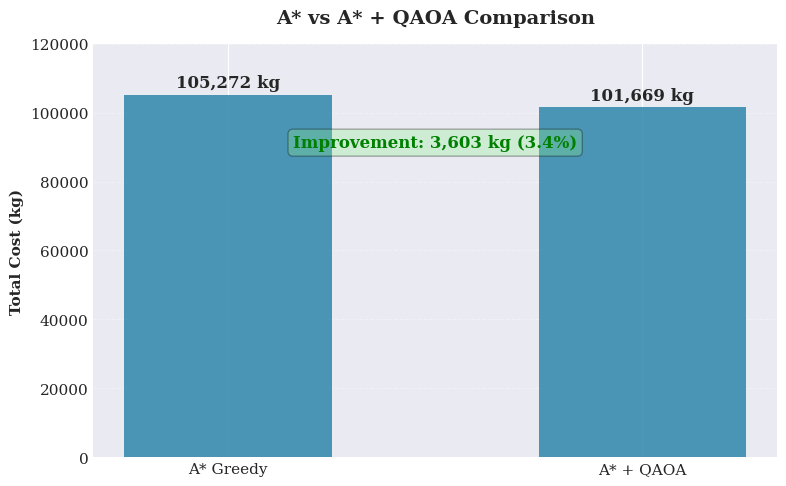


Showing QAOA Circuit...


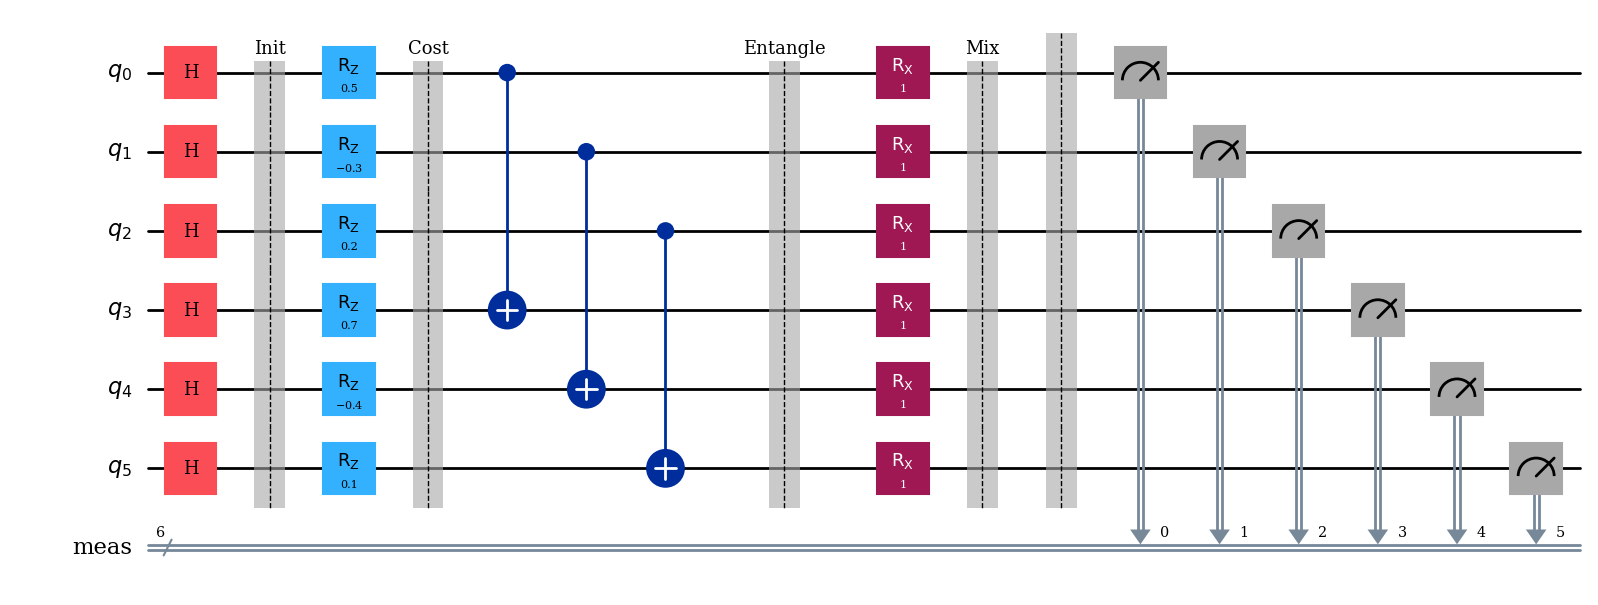

In [21]:

"""
IrisPathQ Simple Visualization
Just bar chart and circuit diagram
"""
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
%matplotlib inline
from qiskit.visualization import circuit_drawer

plt.rcParams['font.size'] = 11

# ============================================================
# BAR CHART: A* vs A* + QAOA
# ============================================================
def show_comparison():
    fig, ax = plt.subplots(figsize=(8, 5))
    
    methods = ['A* Greedy', 'A* + QAOA']
    total_costs = [105272, 101669]
    
    bars = ax.bar(methods, total_costs, color='#2E86AB', width=0.5, alpha=0.85)
    
    # Add values on bars
    for bar, cost in zip(bars, total_costs):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
                f'{cost:,} kg',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    # Show improvement
    savings = 105272 - 101669
    pct = (savings / 105272) * 100
    ax.text(0.5, 90000, f'Improvement: {savings:,} kg ({pct:.1f}%)', 
            ha='center', fontsize=12, color='green', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.3))
    
    ax.set_ylabel('Total Cost (kg)', fontweight='bold')
    ax.set_title('A* vs A* + QAOA Comparison', fontweight='bold', fontsize=14, pad=15)
    ax.set_ylim(0, 120000)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    plt.tight_layout()
    plt.show()

# ============================================================
# QAOA CIRCUIT (2 flights = 6 qubits)
# ============================================================
def show_circuit():
    qc = QuantumCircuit(6)
    
    # Initial superposition
    qc.h(range(6))
    qc.barrier(label='Init')
    
    # Cost Hamiltonian
    qc.rz(0.5, 0)
    qc.rz(-0.3, 1)
    qc.rz(0.2, 2)
    qc.rz(0.7, 3)
    qc.rz(-0.4, 4)
    qc.rz(0.1, 5)
    qc.barrier(label='Cost')
    
    # Entanglement (conflicts)
    qc.cx(0, 3)
    qc.cx(1, 4)
    qc.cx(2, 5)
    qc.barrier(label='Entangle')
    
    # Mixing
    qc.rx(1.0, 0)
    qc.rx(1.0, 1)
    qc.rx(1.0, 2)
    qc.rx(1.0, 3)
    qc.rx(1.0, 4)
    qc.rx(1.0, 5)
    qc.barrier(label='Mix')
    
    # Measure
    qc.measure_all()
    
    # Draw
    qc.draw('mpl', style='iqp', fold=-1)
    plt.tight_layout()
    plt.show()

# ============================================================
# RUN
# ============================================================
if __name__ == "__main__":
    print("Showing Bar Chart...")
    show_comparison()
    
    print("\nShowing QAOA Circuit...")
    show_circuit()

In [17]:
!pip install qiskit


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
from qiskit import QuantumCircuit